# 01: Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the fraud detection dataset.

## Setup

In [0]:
%pip install --upgrade matplotlib

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("FraudDetectionEDA") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.0


## Load Data

In [0]:
# Define data path
data_path = "/Workspace/Users/mohamed.c.elshenity@gmail.com/fraud/parquet"

# Load data
df = spark.read.parquet(data_path)

# Show basic info
print(f"Total records: {df.count():,}")
print(f"Total columns: {len(df.columns)}")
df.printSchema()

Total records: 342,566
Total columns: 26
root
 |-- ssn: string (nullable = true)
 |-- cc_num: string (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- long: string (nullable = true)
 |-- city_pop: string (nullable = true)
 |-- job: string (nullable = true)
 |-- dob: string (nullable = true)
 |-- acct_num: string (nullable = true)
 |-- profile: string (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- trans_date: string (nullable = true)
 |-- trans_time: string (nullable = true)
 |-- unix_time: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: string (nullable = true)
 |-- is_fraud: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- merch_lat: string (nullable = true)
 |

In [0]:
# Show sample data
df.show(5, truncate=False)

+-----------+----------------+------+-------+------+--------------------+---------+-----+-----+------+--------+--------+------------------+----------+------------+-----------------------------+--------------------------------+----------+----------+----------+-------------+-----+--------+-------------------------------+---------+----------+
|ssn        |cc_num          |first |last   |gender|street              |city     |state|zip  |lat   |long    |city_pop|job               |dob       |acct_num    |profile                      |trans_num                       |trans_date|trans_time|unix_time |category     |amt  |is_fraud|merchant                       |merch_lat|merch_long|
+-----------+----------------+------+-------+------+--------------------+---------+-----+-----+------+--------+--------+------------------+----------+------------+-----------------------------+--------------------------------+----------+----------+----------+-------------+-----+--------+----------------------------

## Label Distribution

Label Distribution:
 is_fraud  count  percentage
        1   7888    2.302622
        0 334678   97.697378


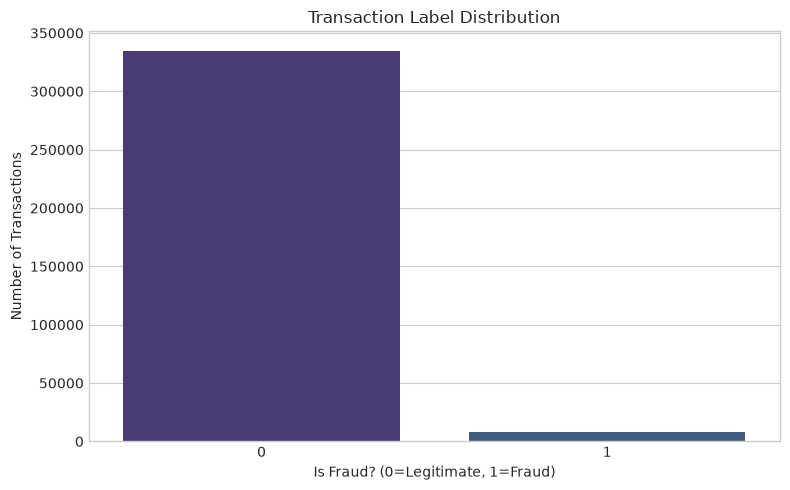

In [0]:
# Convert is_fraud to integer
df = df.withColumn("is_fraud", F.col("is_fraud").cast("integer"))

# Calculate label distribution
label_dist = df.groupBy("is_fraud").count().toPandas()
label_dist["percentage"] = (label_dist["count"] / df.count()) * 100

print("Label Distribution:")
print(label_dist.to_string(index=False))

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=label_dist, x="is_fraud", y="count", hue="is_fraud", legend=False)
plt.title("Transaction Label Distribution")
plt.xlabel("Is Fraud? (0=Legitimate, 1=Fraud)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

## Amount Distribution

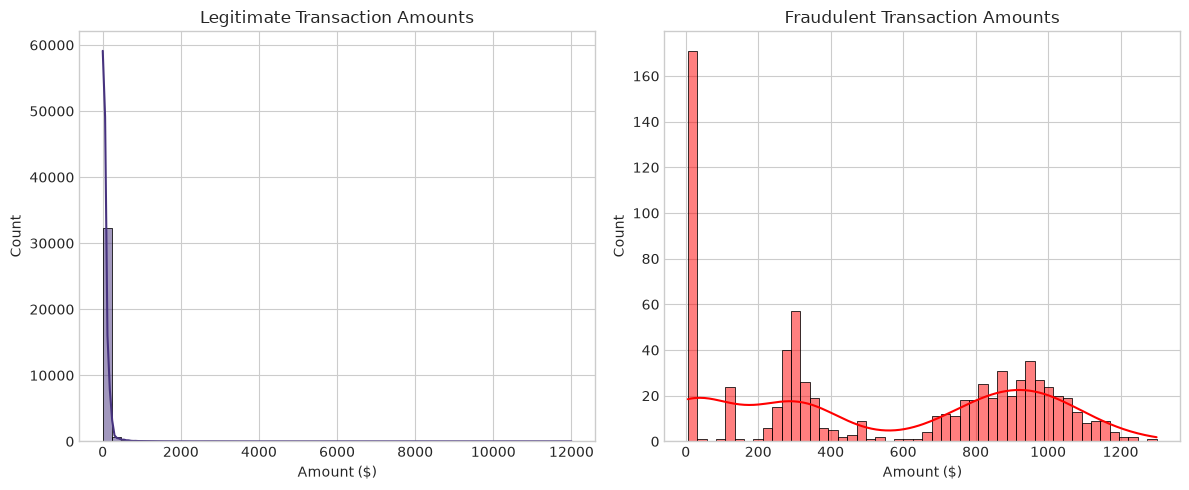

In [0]:
# Convert amount to double
df = df.withColumn("amt", F.col("amt").cast("double"))

# Sample data for plotting
sample_df = df.select("amt", "is_fraud").sample(fraction=0.1, seed=42).toPandas()

# Plot distribution by label
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=sample_df[sample_df["is_fraud"] == 0], x="amt", bins=50, kde=True)
plt.title("Legitimate Transaction Amounts")
plt.xlabel("Amount ($)")

plt.subplot(1, 2, 2)
sns.histplot(data=sample_df[sample_df["is_fraud"] == 1], x="amt", bins=50, kde=True, color="red")
plt.title("Fraudulent Transaction Amounts")
plt.xlabel("Amount ($)")

plt.tight_layout()
plt.show()

## Category Analysis

Top 10 Categories by Fraud Rate:
     category  total_txn  fraud_rate
 shopping_net      27061    0.065593
     misc_net      15467    0.061033
  grocery_pos      32649    0.051671
 shopping_pos      35519    0.028351
gas_transport      27286    0.019754
     misc_pos      21804    0.012567
       travel      10899    0.012019
entertainment      24160    0.010637
personal_care      26184    0.010579
  food_dining      25010    0.009316


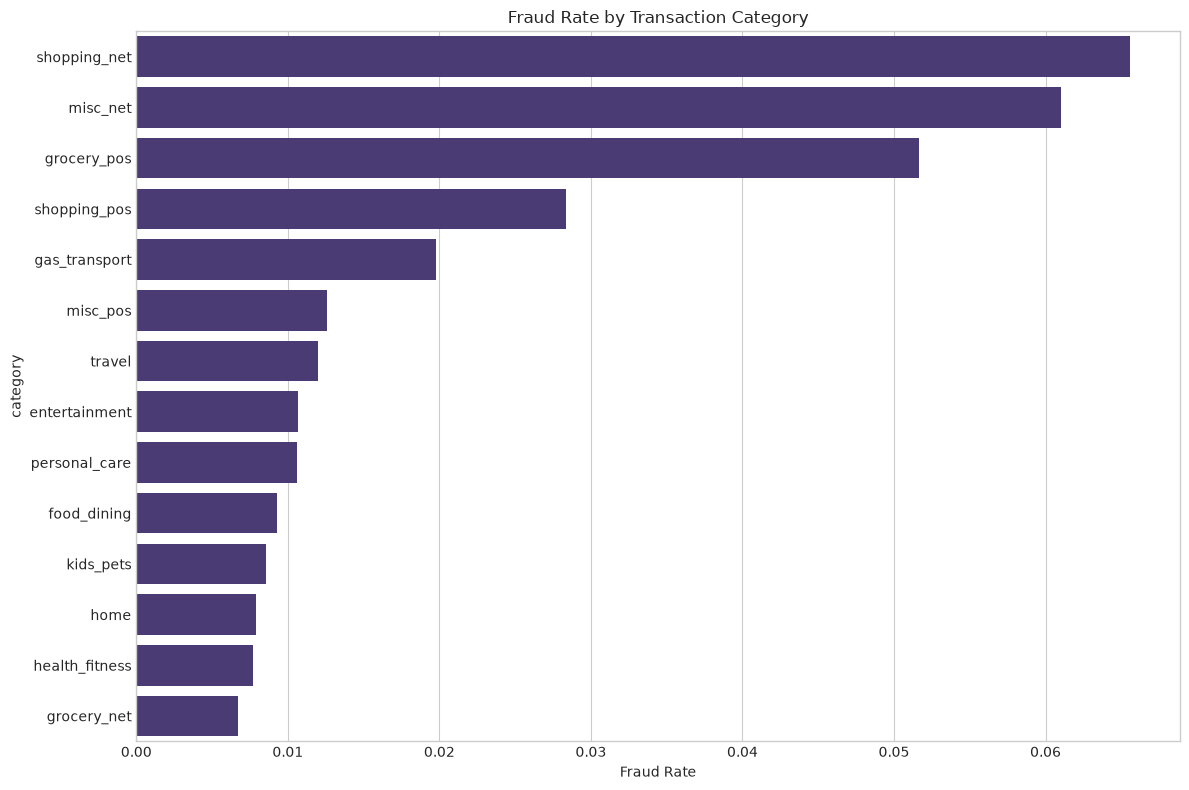

In [0]:
# Fraud rate by category
category_stats = df.groupBy("category").agg(
    F.count("*").alias("total_txn"),
    F.avg("is_fraud").alias("fraud_rate")
).orderBy(F.desc("fraud_rate")).toPandas()

print("Top 10 Categories by Fraud Rate:")
print(category_stats.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=category_stats, y="category", x="fraud_rate", orient="h")
plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate")
plt.tight_layout()
plt.show()

## Stop Spark Session

In [0]:
spark.stop()